# Method 3: LSD (Line Segment Detector) on Skeletonized Image
Uses adaptive mean thresholding + skeletonization to produce clean 1-pixel-wide edges, then applies `cv2.createLineSegmentDetector` for line detection.

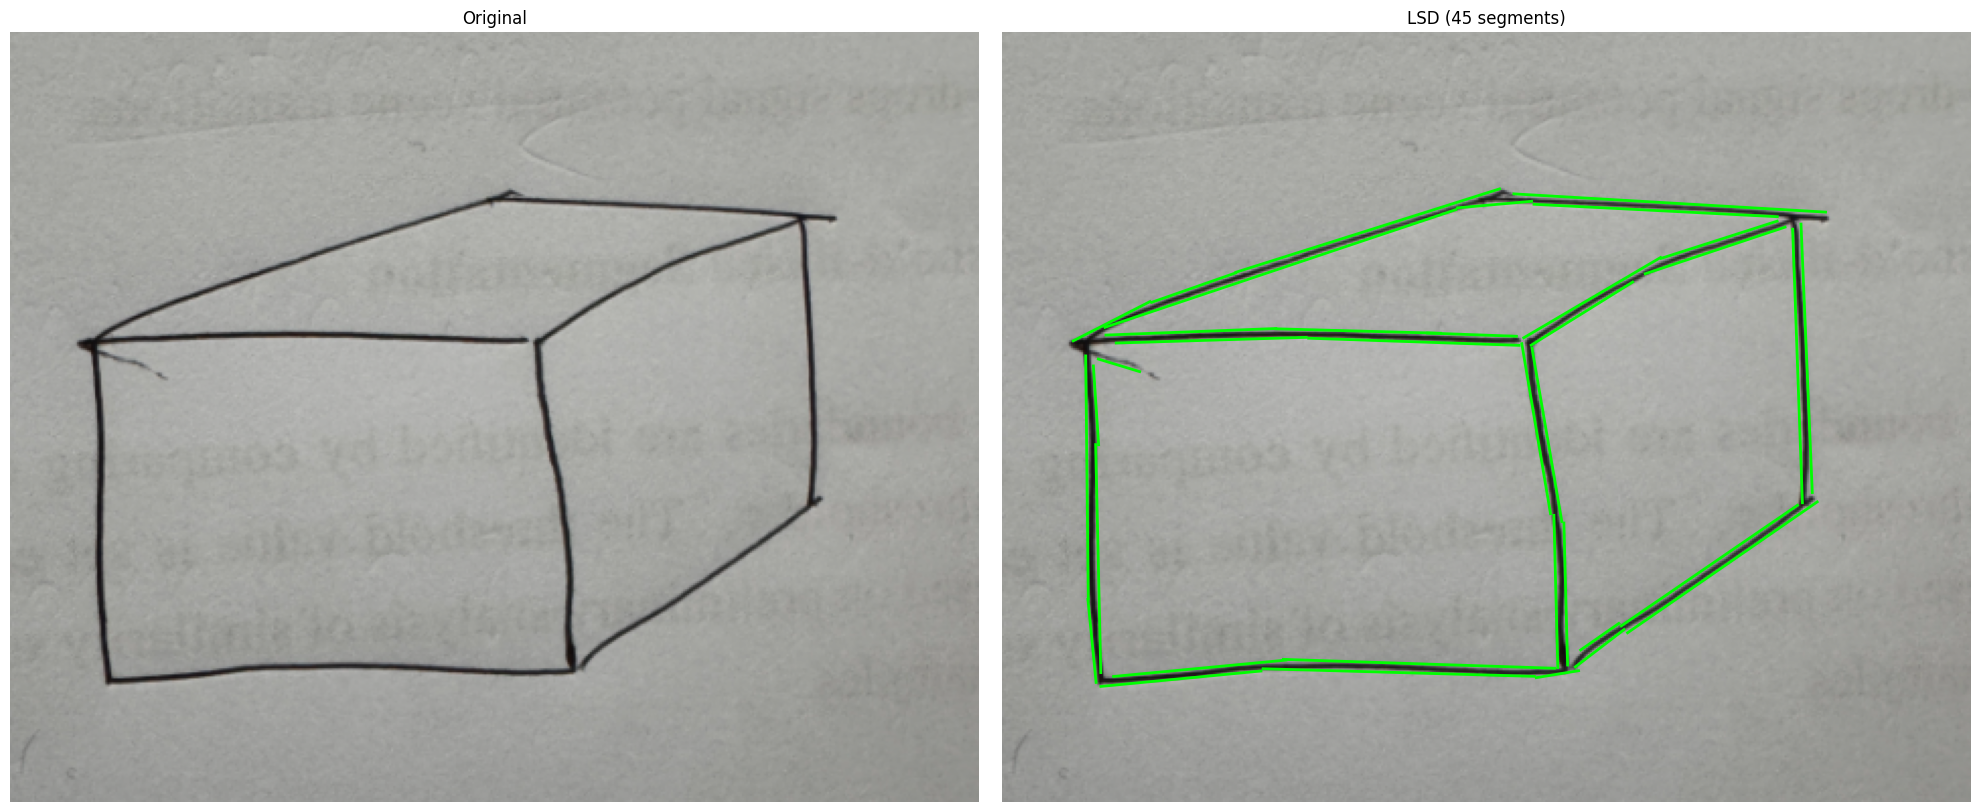

Total LSD segments: 45, shown (>= 20px): 36


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

img_color = cv2.imread('cuboid.png')
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)

# Adaptive mean threshold → morph clean → CC filter → skeletonize
binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 51, 15)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# Remove small connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
min_area = 200
clean = np.zeros_like(binary)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        clean[labels == i] = 255

# Skeletonize to 1-pixel-wide lines
skeleton = skeletonize(clean > 0).astype(np.uint8) * 255

# LSD on skeleton — convert to grayscale-like image (invert so lines are dark on white)
skeleton_gray = 255 - skeleton
lsd = cv2.createLineSegmentDetector(cv2.LSD_REFINE_STD)
lines, widths, precs, nfas = lsd.detect(skeleton_gray)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(skeleton, cmap='gray'); axes[1].set_title('Skeleton'); axes[1].axis('off')
axes[2].imshow(img_rgb)
axes[2].axis('off')

# Filter: only keep segments longer than minimum length
min_length = 20
count = 0
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.hypot(x2 - x1, y2 - y1)
        if length >= min_length:
            axes[2].plot([x1, x2], [y1, y2], color='lime', linewidth=2)
            count += 1

total = len(lines) if lines is not None else 0
axes[2].set_title(f'LSD on Skeleton ({count} segments >= {min_length}px)')
plt.tight_layout()
fig.savefig('result_lsd.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total LSD segments: {total}, shown (>= {min_length}px): {count}')